# *Laboratório II (n2) - Processamento Digital de Imagens -  Prof. Dr. Cassio Vinhal*

Pedro Cézar S. Ferreira -  202302579 - Eng. de Computação

# Separabilidade, Suavização, Filtros Não Lineares e Detecção de Bordas por Derivadas de Primeira Ordem

### Roteiro

- **Parte 1** — Suavização e Separabilidade (Filtros Gaussianos)
- **Parte 2** — Mediana, Sal e Pimenta (Filtros Não Lineares)
- **Parte 3** — Bordas e Prewitt (Derivadas Discretas)
- **Parte 4** — Bordas e Sobel (Comparação de Máscaras)


In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import time
from scipy.signal import convolve2d
from scipy.ndimage import convolve1d, gaussian_filter, median_filter

def show_images(images, titles, cmap='gray', cols=2, figsize=(15, 10)):
    n = len(images)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = axes.flatten()
    for i in range(len(axes)):
        if i < n:
            axes[i].imshow(images[i], cmap=cmap, vmin=0, vmax=255)
            axes[i].set_title(titles[i])
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()


## Parte 1: Suavização e Separabilidade

Nesta parte, vamos explorar a propriedade de separabilidade do filtro gaussiano.
A convolução bidimensional direta possui complexidade $O(MNk^2)$, enquanto a convolução separável possui complexidade $O(MNk)$.
Para kernels grandes, essa diferença se torna muito expressiva.

Abaixo, mediremos o tempo de execução rigorosamente apenas da operação de filtragem para diferentes tamanhos de kernel.


Kernel Size     Tempo Direta (s)     Tempo Separável (s)  Razão (Direta/Sep)
---------------------------------------------------------------------------
3               0.0131               0.0046               2.8473
5               0.0237               0.0047               5.0800
9               0.0725               0.0070               10.3227
15              0.1101               0.0100               10.9584
31              0.1188               0.0210               5.6494
51              0.1486               0.0493               3.0128


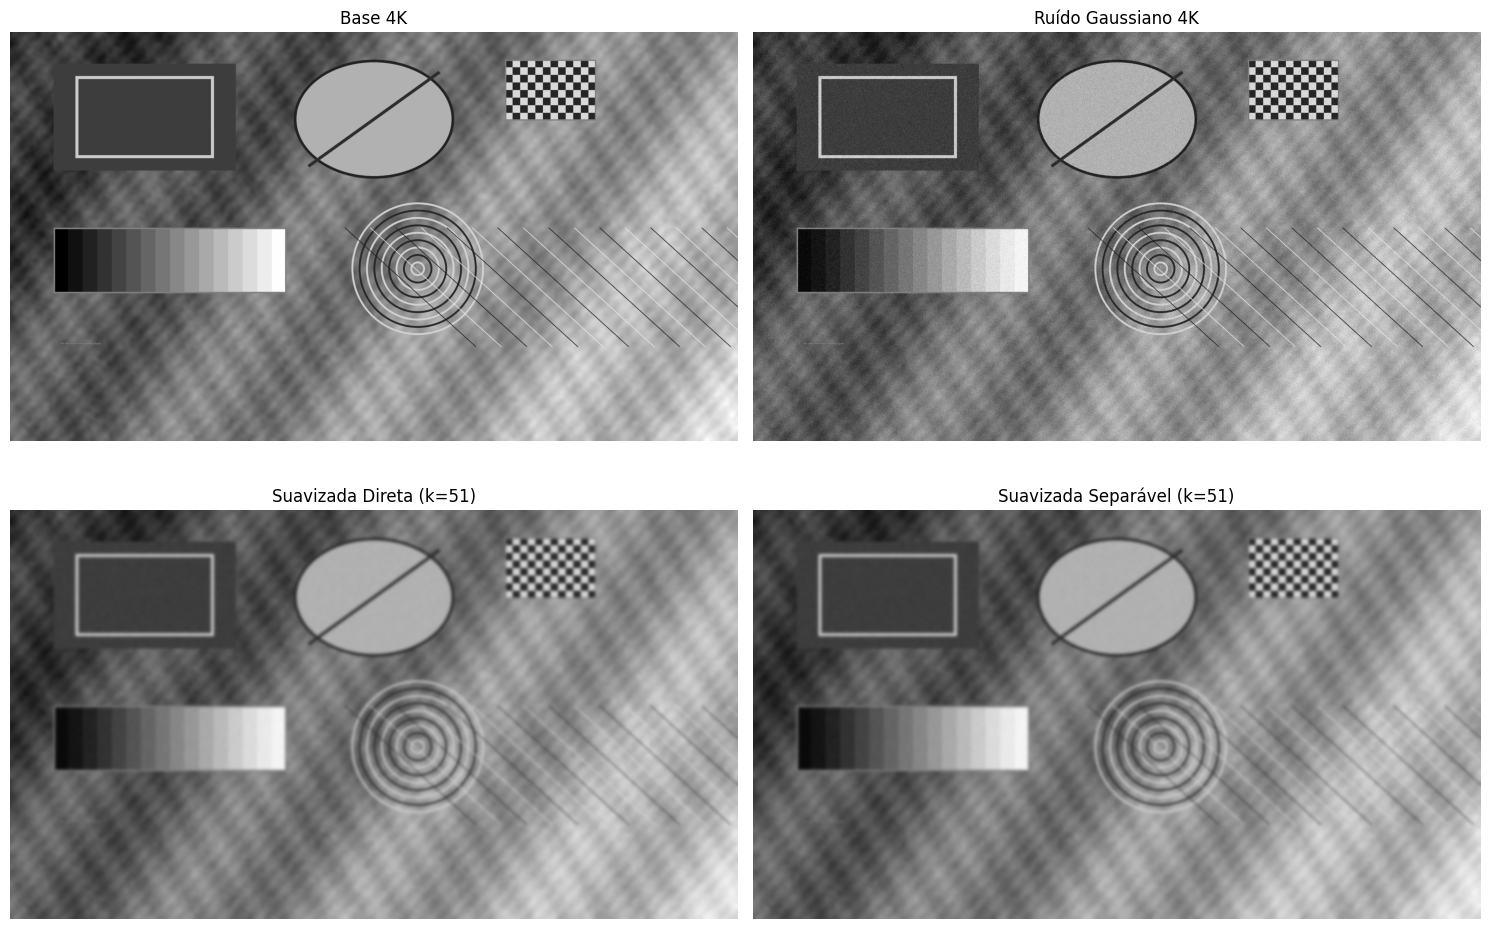

In [17]:
# Carregar a imagem 4K com ruído gaussiano
img_4k_noise = cv2.imread('imagens_cinza_pdi_filtragem/imagemA4K_ruido_gaussiano_sigma25.png', cv2.IMREAD_GRAYSCALE)
img_4k_base = cv2.imread('imagens_cinza_pdi_filtragem/imagemA4K_base.png', cv2.IMREAD_GRAYSCALE)

# Para kernels grandes, a imagem 4K demora muito. Faremos um resize se necessário, mas como pedido, testaremos {3, 5, 9, 15, 31, 51} na imagem em alta resolução.
kernel_sizes = [3, 5, 9, 15, 31, 51]
# Se estiver usando imagem 4K e o tempo de execução for aceitável, pode testar maiores como 71 ou 101
# kernel_sizes = [3, 5, 9, 15, 31, 51, 71]

def get_gaussian_kernel_1d(k, sigma=None):
    if sigma is None:
        sigma = 0.3 * ((k - 1) * 0.5 - 1) + 0.8
    ax = np.linspace(-(k - 1) / 2., (k - 1) / 2., k)
    kernel = np.exp(-0.5 * np.square(ax) / np.square(sigma))
    return kernel / np.sum(kernel)

def get_gaussian_kernel_2d(k, sigma=None):
    kernel_1d = get_gaussian_kernel_1d(k, sigma)
    kernel_2d = np.outer(kernel_1d, kernel_1d)
    return kernel_2d

times_direct = []
times_separable = []

# Exemplo de imagens suavizadas para mostrar (utilizaremos o último kernel processado)
img_smoothed_direct = None
img_smoothed_separable = None

print(f"{'Kernel Size':<15} {'Tempo Direta (s)':<20} {'Tempo Separável (s)':<20} {'Razão (Direta/Sep)'}")
print("-" * 75)

for k in kernel_sizes:
    k2d = get_gaussian_kernel_2d(k)
    k1d = get_gaussian_kernel_1d(k)
    
    # Repetições para tirar a média
    n_reps = 3
    t_dir_list = []
    t_sep_list = []
    
    for _ in range(n_reps):
        # Convolução Direta
        start = time.time()
        # Usamos cv2.filter2D que é altamente otimizado
        res_dir = cv2.filter2D(img_4k_noise, -1, k2d)
        t_dir_list.append(time.time() - start)
        
        # Convolução Separável
        start = time.time()
        res_sep = cv2.sepFilter2D(img_4k_noise, -1, k1d, k1d)
        t_sep_list.append(time.time() - start)
        
    avg_t_dir = np.mean(t_dir_list)
    avg_t_sep = np.mean(t_sep_list)
    
    times_direct.append(avg_t_dir)
    times_separable.append(avg_t_sep)
    
    razao = avg_t_dir / avg_t_sep if avg_t_sep > 0 else 0
    print(f"{k:<15} {avg_t_dir:<20.4f} {avg_t_sep:<20.4f} {razao:.4f}")
    
    if k == kernel_sizes[-1]:
        img_smoothed_direct = res_dir
        img_smoothed_separable = res_sep

show_images([img_4k_base, img_4k_noise, img_smoothed_direct, img_smoothed_separable], 
            ["Base 4K", "Ruído Gaussiano 4K", f"Suavizada Direta (k={kernel_sizes[-1]})", f"Suavizada Separável (k={kernel_sizes[-1]})"])


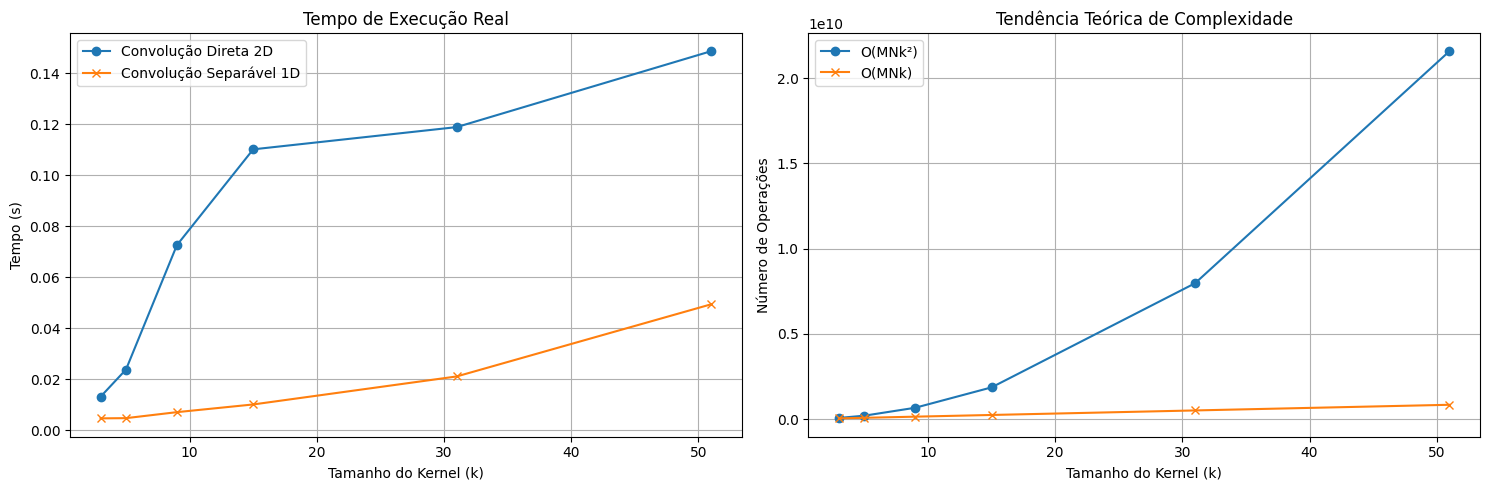

In [18]:
# Gráficos de Complexidade e Tempos

M = img_4k_noise.shape[0]
N = img_4k_noise.shape[1]

# Tendência teórica
k_array = np.array(kernel_sizes)
O_direct = M * N * (k_array ** 2)
O_separable = M * N * (2 * k_array)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico de tempo medido
axes[0].plot(kernel_sizes, times_direct, marker='o', label='Convolução Direta 2D')
axes[0].plot(kernel_sizes, times_separable, marker='x', label='Convolução Separável 1D')
axes[0].set_xlabel('Tamanho do Kernel (k)')
axes[0].set_ylabel('Tempo (s)')
axes[0].set_title('Tempo de Execução Real')
axes[0].legend()
axes[0].grid(True)

# Gráfico de complexidade teórica
axes[1].plot(kernel_sizes, O_direct, marker='o', label='O(MNk²)')
axes[1].plot(kernel_sizes, O_separable, marker='x', label='O(MNk)')
axes[1].set_xlabel('Tamanho do Kernel (k)')
axes[1].set_ylabel('Número de Operações')
axes[1].set_title('Tendência Teórica de Complexidade')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


### Discussão: Separabilidade e Custo Computacional

**Por que a separabilidade reduz o custo computacional?**
A convolução bidimensional direta exige aplicar um kernel $k \times k$ sobre cada pixel, resultando em aproximadamente $k^2$ operações por pixel. A complexidade total assintótica fica em $O(MNk^2)$. Com a propriedade de separabilidade, o kernel bidimensional gaussiano pode ser decomposto em dois kernels unidimensionais. Assim, aplica-se uma convolução na horizontal e em seguida na vertical, gastando $k$ operações na primeira e $k$ operações na segunda passagem ($2k$ no total por pixel). A complexidade cai para $O(MNk)$.

**Em quais tamanhos de kernel a diferença ficou mais evidente?**
A diferença de tempo de execução tende a ficar brutalmente evidente nos tamanhos de kernel maiores, como $k=31$, $k=51$ e superiores. Nesses casos o comportamento assintótico dita completamente o tempo.

**Por que as curvas medidas experimentalmente podem não coincidir exatamente com as curvas teóricas?**
O custo $O(MNk^2)$ é apenas o número de operações puramente matemáticas. Tempos reais medidos em software levam em consideração otimizações de nível de máquina.
- **Otimizações de Bibliotecas:** O OpenCV (`cv2.filter2D`) faz paralelização interna, vetorização SIMD (AVX/SSE) e outras micro-otimizações. 
- **Cache de Memória:** O acesso não-contíguo de memória durante a convolução ao longo do eixo Y pode aumentar o tempo da versão separável, devido a "cache misses", amortecendo ligeiramente a enorme vantagem teórica do número reduzido de instruções.
- **Overhead de Chamadas:** Em kernels muito pequenos ($3 \times 3$), o tempo extra para empilhar chamadas de funções de convolução 1D duplicadas e lidar com alocações temporárias compensa o fato de ter que fazer $9$ multiplicações contra $6$. Portanto, em kernels menores a performance teórica não dita com exatidão a vantagem real.

No entanto, mesmo com bibliotecas altamente otimizadas, a versão separável supera massivamente a direta à medida que os tamanhos das máscaras escalam.


## Parte 2: Mediana, Sal e Pimenta

Enquanto o ruído gaussiano é bem tratado por filtros lineares, o ruído impulsivo (sal e pimenta) exige filtros robustos a outliers. Filtros lineares vão simplesmente "borrar" e espalhar a intensidade dos pixels pretos e brancos extremos para os arredores, não efetivamente os removendo.

O filtro de mediana resolve isso, substituindo o valor de cada pixel pela mediana estatística da vizinhança local.


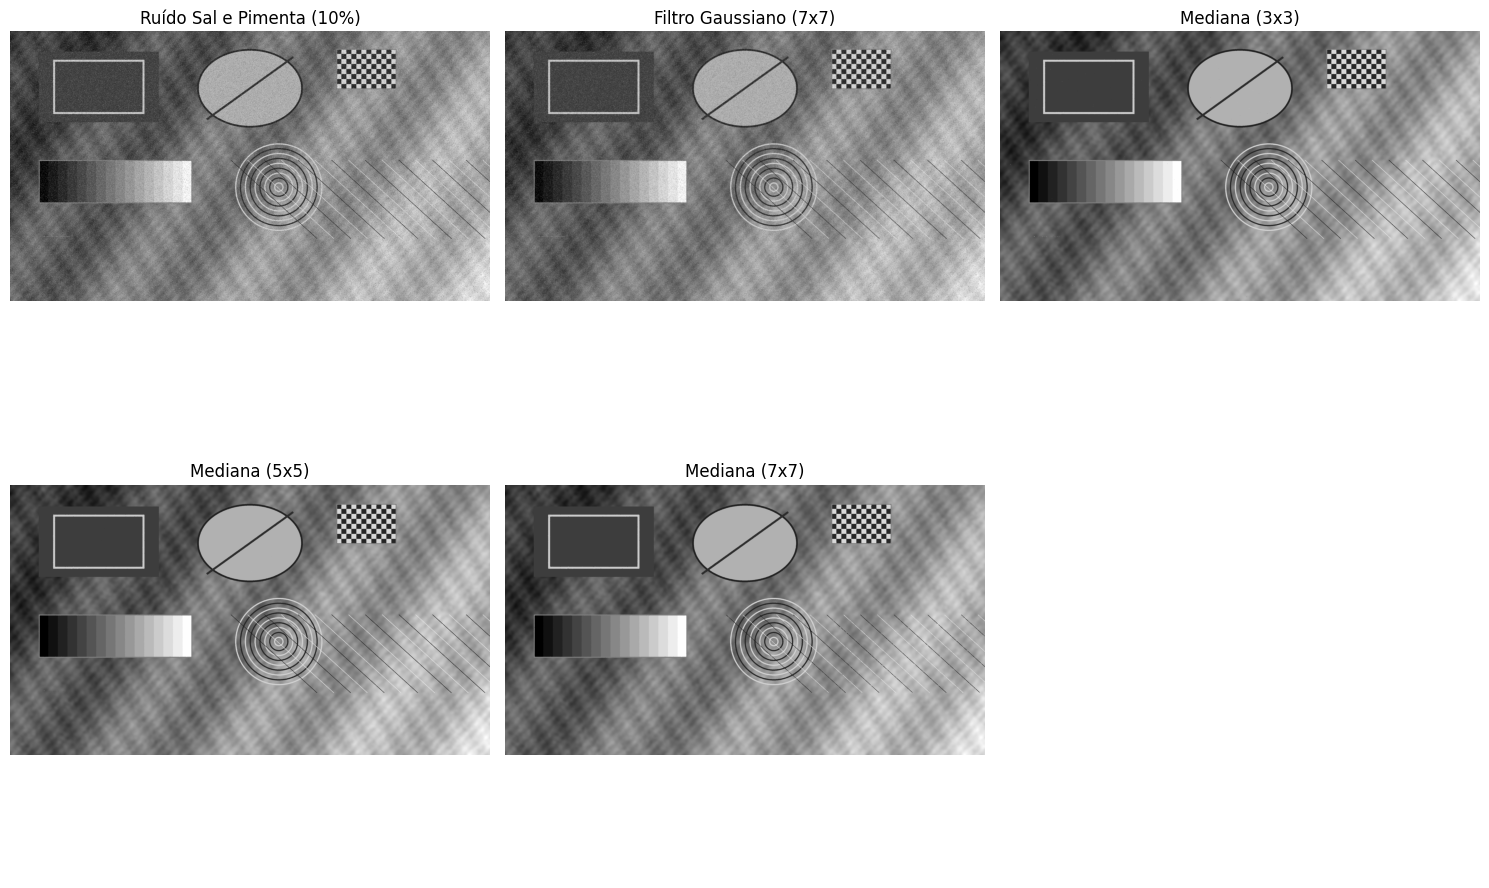

In [19]:
# Carregar a imagem com ruído sal e pimenta
img_sp = cv2.imread('imagens_cinza_pdi_filtragem/imagemA4K_ruido_sal_pimenta_10pct.png', cv2.IMREAD_GRAYSCALE)

# Filtros
gauss_smoothed = cv2.GaussianBlur(img_sp, (7, 7), 0)
median_3x3 = cv2.medianBlur(img_sp, 3)
median_5x5 = cv2.medianBlur(img_sp, 5)
median_7x7 = cv2.medianBlur(img_sp, 7)

# Exibição
images_p2 = [img_sp, gauss_smoothed, median_3x3, median_5x5, median_7x7]
titles_p2 = ['Ruído Sal e Pimenta (10%)', 'Filtro Gaussiano (7x7)', 'Mediana (3x3)', 'Mediana (5x5)', 'Mediana (7x7)']

show_images(images_p2, titles_p2, cols=3, figsize=(15, 10))


### Discussão: Eficácia do Filtro de Mediana e Compromisso (Trade-off)

**Por que a mediana é mais adequada para ruído Sal e Pimenta?**
Como a mediana escolhe o "valor do meio" num array ordenado da vizinhança, pixels de ruído salt/pepper (que por definição estouram nos valores mínimos ou máximos de intensidade) estarão sempre nos extremos do ranking e nunca no meio, sendo simplesmente descartados e substituídos pela intensidade do fundo subjacente. Ao invés disso, filtros lineares incorporam os valores espúrios na conta da média, deixando o borrão ruidoso no entorno.

**O Efeito do aumento do tamanho da janela (trade-off):**
Aumentando a janela da mediana de $3\times3$ para $7\times7$, reparamos numa limpeza muito mais efetiva de agregados mais densos de ruído. Porém, como pontuado em *Burger and Burge (2022) Figura 5.14*, o custo de usar grandes vizinhanças é uma forte perda de estrutura: texturas finas, arestas afiadas e pequenos pontos isolados sofrem uma intensa erosão/arredondamento, tornando a imagem um pouco plastificada, o que caracteriza o trade-off prático do tamanho da janela.


## Parte 3: Bordas e Prewitt

Bordas ocorrem em locais de variação brusca de intensidade. A operação clássica para detecção consiste em aproximar derivadas de primeira ordem através de máscaras espaciais de diferença discreta. O método de Prewitt engloba a derivada direcional com uma pequena média ortogonal.

Vamos calcular as componentes $G_x$ e $G_y$ usando a imagem `FullHD`.


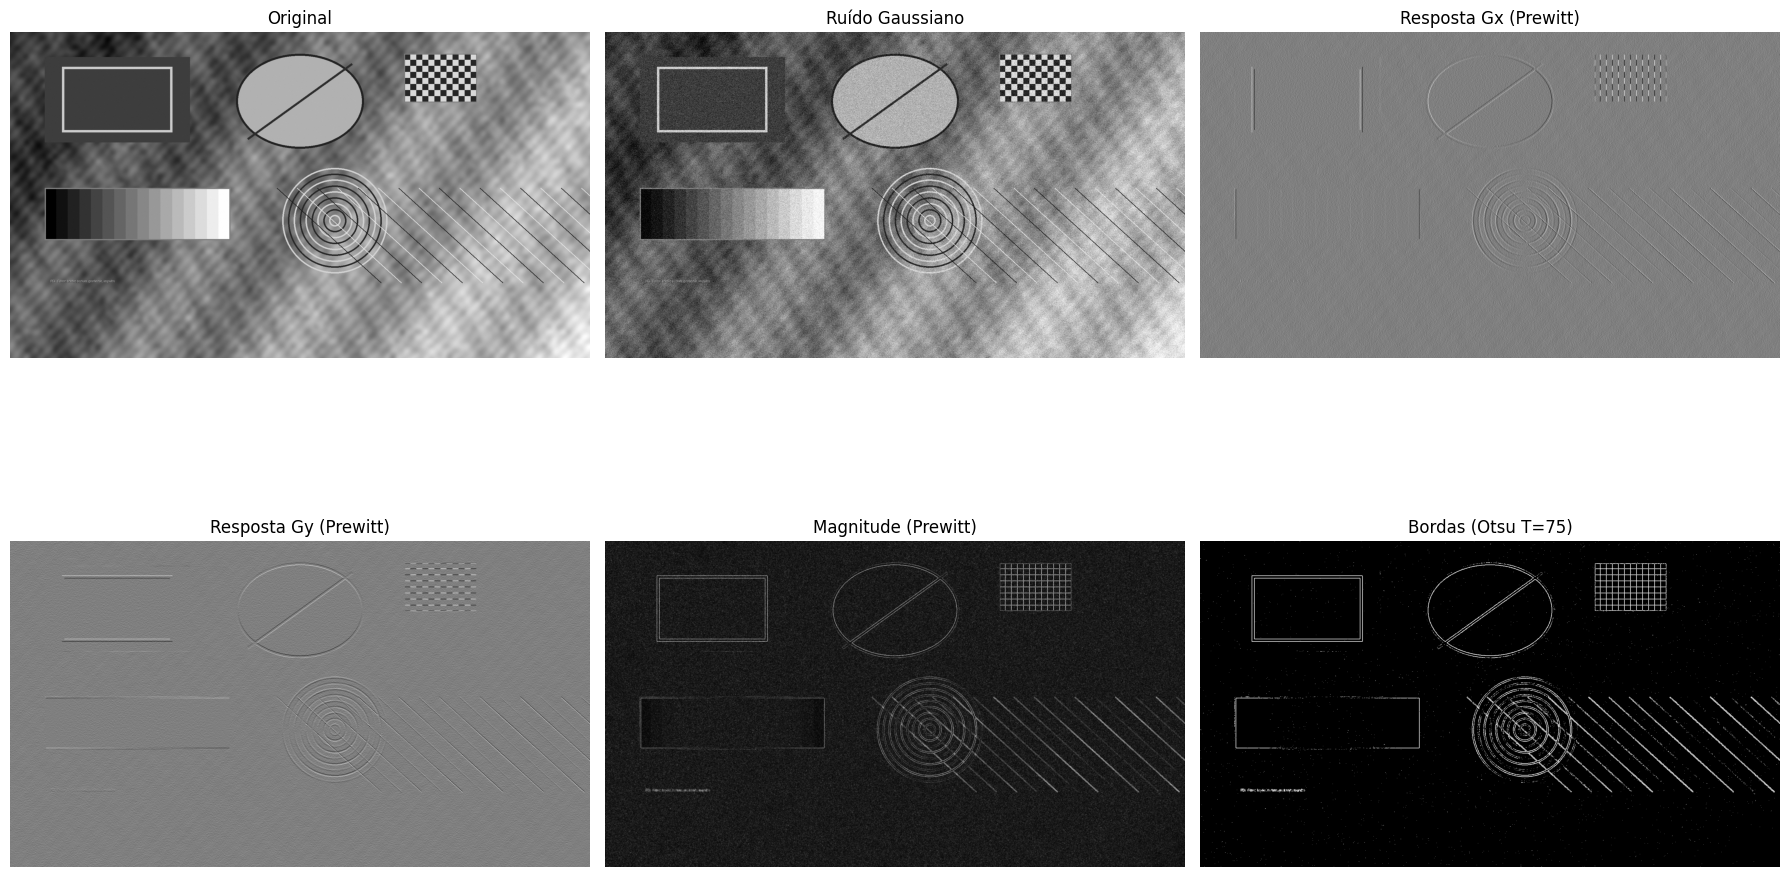

In [20]:
# Carregar Imagens
img_fhd_base = cv2.imread('imagens_cinza_pdi_filtragem/imagemAFullHD_base.png', cv2.IMREAD_GRAYSCALE)
img_fhd_noise = cv2.imread('imagens_cinza_pdi_filtragem/imagemAFullHD_ruido_gaussiano_sigma25.png', cv2.IMREAD_GRAYSCALE)

# Conversão para float para suportar valores negativos
img_float = np.float32(img_fhd_noise)

# Máscaras de Prewitt
K_prewitt_x = np.array([[-1, 0, 1],
                        [-1, 0, 1],
                        [-1, 0, 1]], dtype=np.float32)

K_prewitt_y = np.array([[-1, -1, -1],
                        [ 0,  0,  0],
                        [ 1,  1,  1]], dtype=np.float32)

# Ao invés do cv2.filter2D, que faz correlação cruzada, invertendo sinais da resposta dependendo do kernel.
# Gx estima variações ao longo do eixo horizontal; Gy ao longo do vertical.
Gx_prewitt = cv2.filter2D(img_float, cv2.CV_32F, K_prewitt_x)
Gy_prewitt = cv2.filter2D(img_float, cv2.CV_32F, K_prewitt_y)

# Magnitude Euclidiana
G_mag_prewitt = np.sqrt(np.square(Gx_prewitt) + np.square(Gy_prewitt))

# Normalização para visualização (- a + mapeado em 0-255 com cinza em 128)
def normalize_visual(D):
    # O valor 0 se torna 128. Negativos para preto, positivos para branco.
    D_norm = ((D / (np.max(np.abs(D)) + 1e-5)) * 127) + 128
    return np.uint8(np.clip(D_norm, 0, 255))

Gx_vis = normalize_visual(Gx_prewitt)
Gy_vis = normalize_visual(Gy_prewitt)

# Limiarização (Binarização das bordas). Escolhemos Otsu.
G_mag_uint8 = np.uint8(np.clip((G_mag_prewitt / np.max(G_mag_prewitt)) * 255, 0, 255))
ret_otsu, G_thresh = cv2.threshold(G_mag_uint8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

images_p3 = [img_fhd_base, img_fhd_noise, Gx_vis, Gy_vis, G_mag_uint8, G_thresh]
titles_p3 = ['Original', 'Ruído Gaussiano', 'Resposta Gx (Prewitt)', 'Resposta Gy (Prewitt)', 'Magnitude (Prewitt)', f'Bordas (Otsu T={ret_otsu:.0f})']

show_images(images_p3, titles_p3, cols=3, figsize=(18, 12))


### Discussão: Interpretação Gradiental de Prewitt

**Diferenças visuais (Gx e Gy) e Realce:**
- **$G_x$** é obtido através de uma filtragem de diferença finita ao longo do eixo das abscissas. Consequentemente ele mapeia primariamente as **bordas verticais**. Na imagem visual com offset de fundo cinza, as transições escuras-claras na horizontal geram picos claros, e claras-escuras geram vales pretos.
- **$G_y$** faz o mesmo ao longo das ordenadas, mapeando as **bordas horizontais**. 
- A **magnitude** total combina vetorialmente essas energias, resultando num mapa invariante de rotação da "força" da borda.

**Escolha de Limiar:**
O limiar escolhido utilizou o método de **Otsu**, pois ele encontra matematicamente o limiar ótimo que separa as duas classes do histograma bimodular (ruído de fundo versus bordas dominantes).

**A Interferência do Ruído e Derivadas Discretas:**
Derivadas são, por natureza, operadores "Passa-Altas". Elas quantificam instabilidades rápidas de dados adjacentes. Um ruído gaussiano constitui puramente uma energia oscilatória de altíssima frequência imposta num sinal. Quando submetido a uma derivada não-protegida, o ruído é massivamente amplificado porque a máscara diferencial registra toda e qualquer transição estocástica do sinal como se fosse uma borda estrutural local. Isso contamina gravemente o mapa gradiente. É por isso que **procedimentos de pré-suavização são imperativos** na detecção de bordas confiável (como se vê formalizado futuramente nos detectores de Canny/Marr-Hildreth).


## Parte 4: Bordas e Sobel

O operador de Sobel segue o exato mesmo princípio da estimativa de derivadas de primeira ordem do Prewitt, mas propõe uma pequena melhoria: os coeficientes centrais da máscara recebem peso $2$ ao longo do eixo ortogonal da derivada. Isso emula um alisamento gaussiano mais efetivo no sentido que corre paralela à borda.


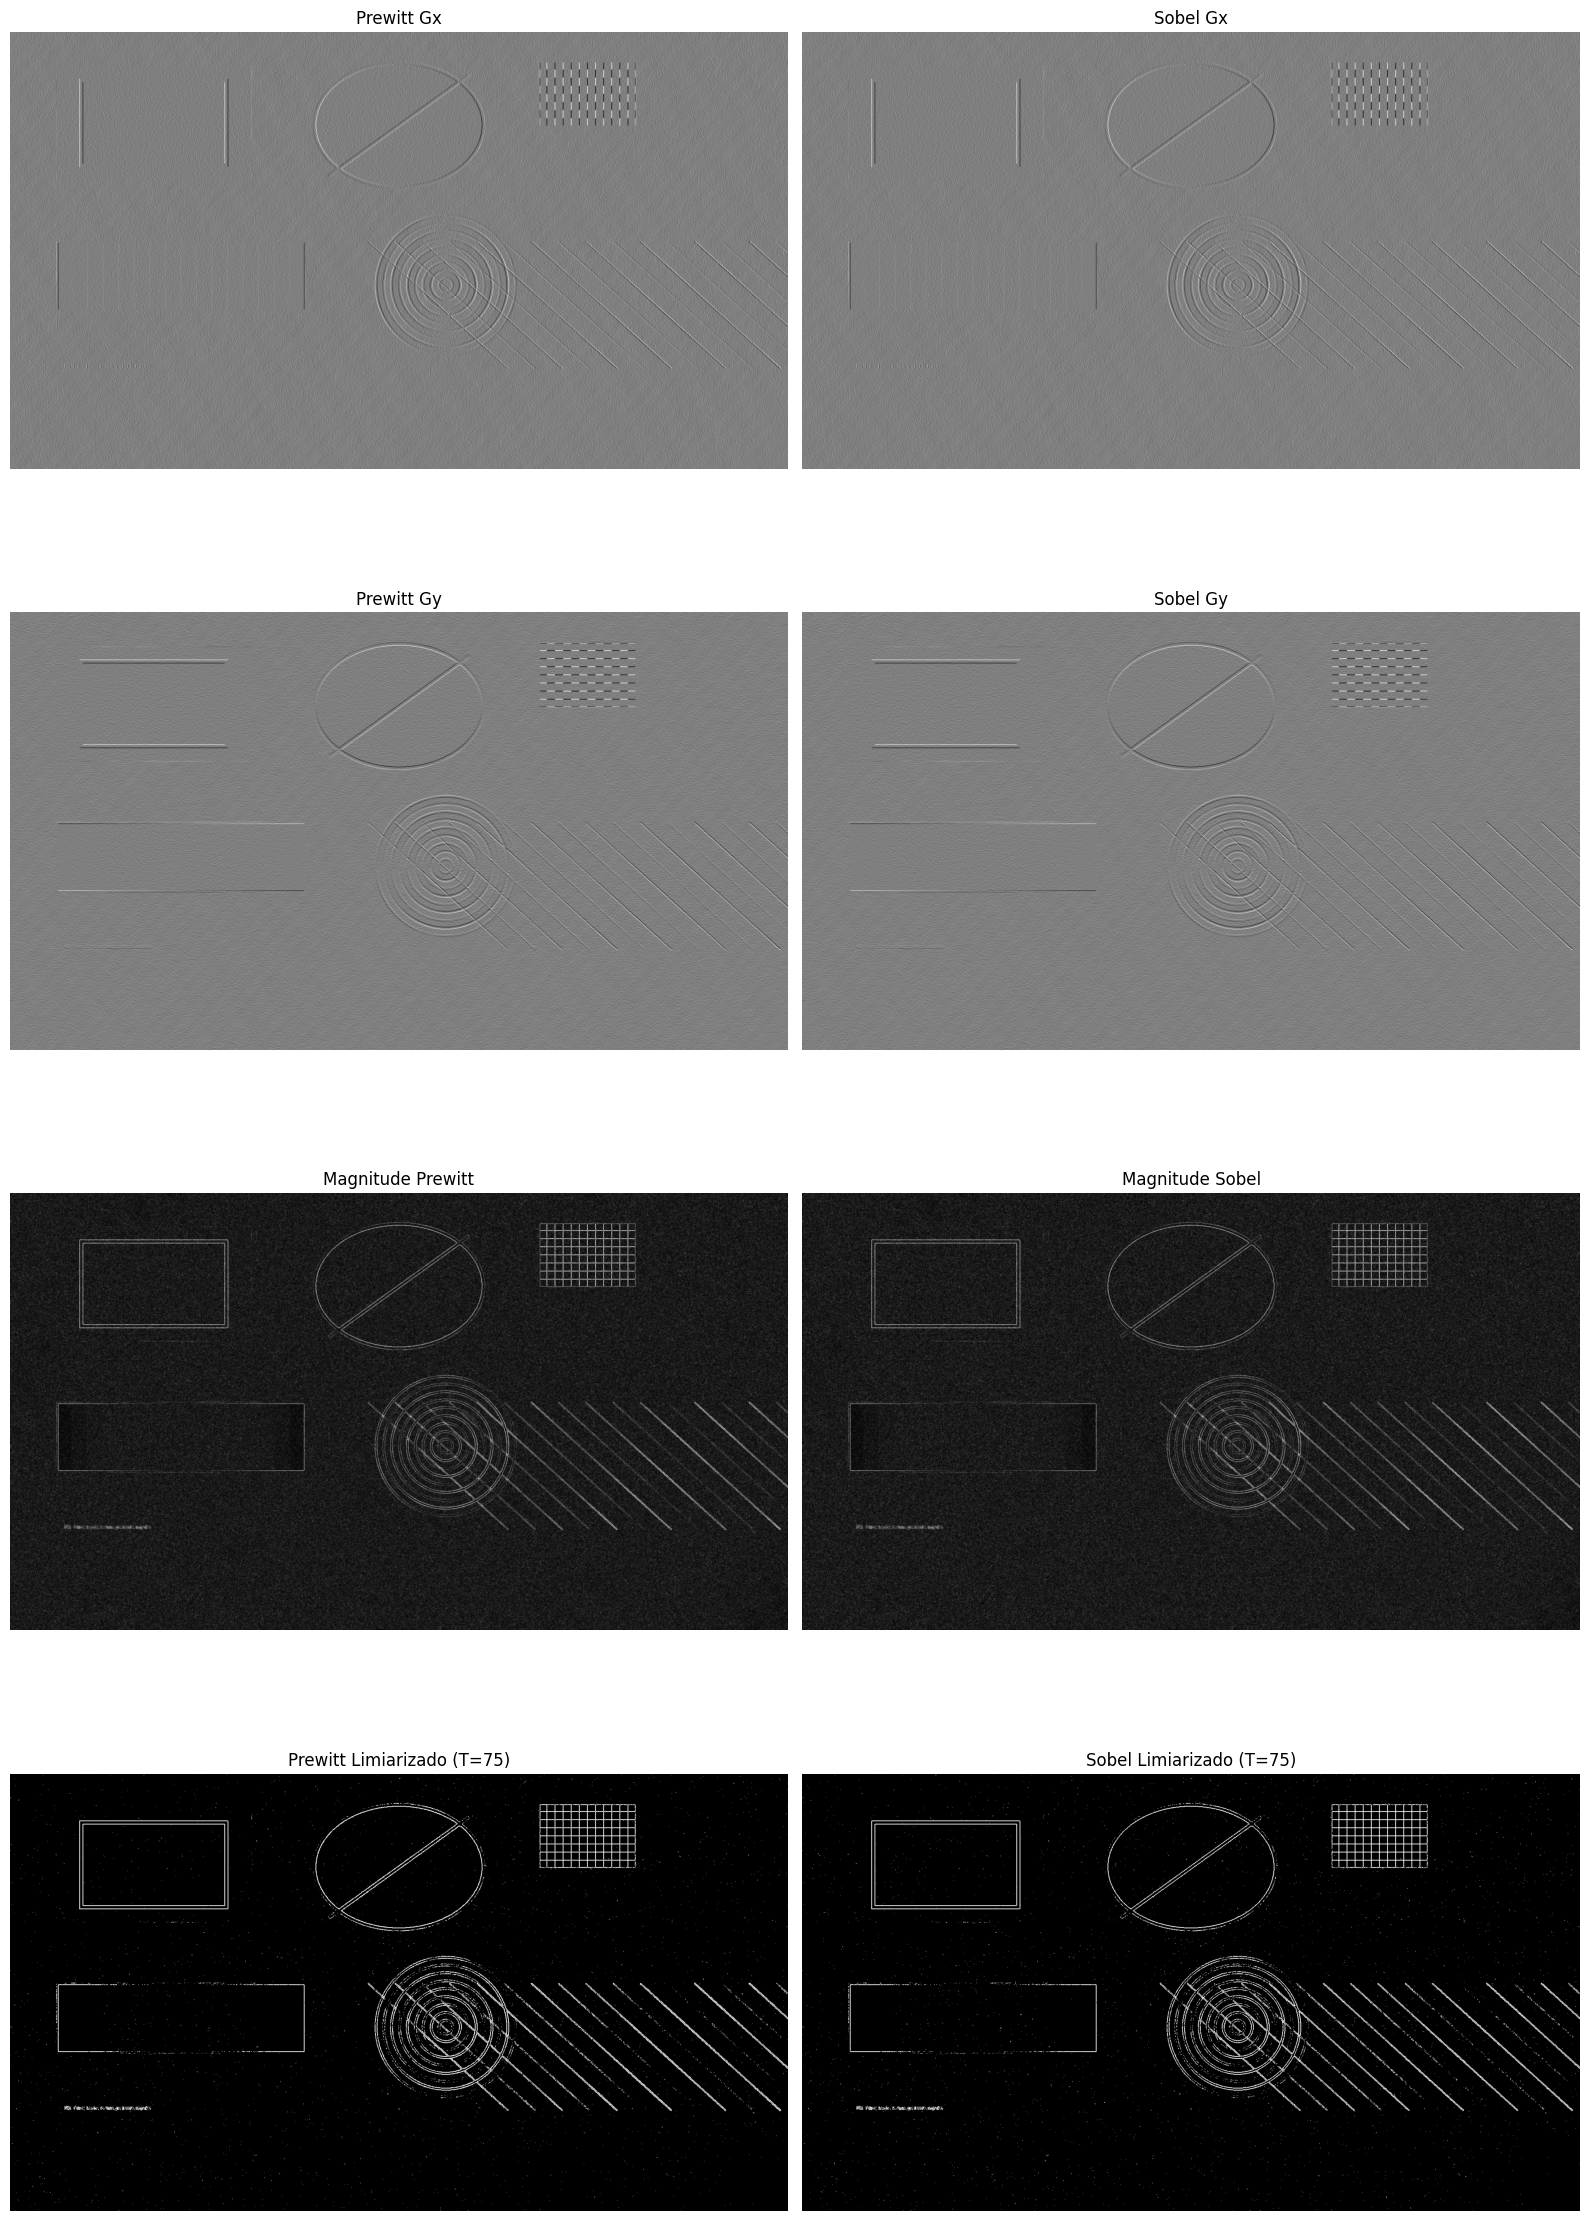

In [21]:
# Máscaras de Sobel (para a MESMA imagem com O MESMO ruído gerado e lido da Parte 3)
K_sobel_x = np.array([[-1, 0, 1],
                      [-2, 0, 2],
                      [-1, 0, 1]], dtype=np.float32)

K_sobel_y = np.array([[-1, -2, -1],
                      [ 0,  0,  0],
                      [ 1,  2,  1]], dtype=np.float32)

Gx_sobel = cv2.filter2D(img_float, cv2.CV_32F, K_sobel_x)
Gy_sobel = cv2.filter2D(img_float, cv2.CV_32F, K_sobel_y)

# Magnitude Sobel
G_mag_sobel = np.sqrt(np.square(Gx_sobel) + np.square(Gy_sobel))

# Normalização idêntica ao Prewitt para comparação correta
Gx_sob_vis = normalize_visual(Gx_sobel)
Gy_sob_vis = normalize_visual(Gy_sobel)

G_mag_sob_uint8 = np.uint8(np.clip((G_mag_sobel / np.max(G_mag_sobel)) * 255, 0, 255))

# Usar O MESMO limiar do Prewitt para manter justiça exata na comparação de binarização.
_, G_thresh_sob = cv2.threshold(G_mag_sob_uint8, ret_otsu, 255, cv2.THRESH_BINARY)

# Apresentação Lado a Lado Prewitt vs Sobel
images_p4 = [Gx_vis, Gx_sob_vis, 
             Gy_vis, Gy_sob_vis, 
             G_mag_uint8, G_mag_sob_uint8,
             G_thresh, G_thresh_sob]
titles_p4 = ['Prewitt Gx', 'Sobel Gx', 
             'Prewitt Gy', 'Sobel Gy', 
             'Magnitude Prewitt', 'Magnitude Sobel',
             f'Prewitt Limiarizado (T={ret_otsu:.0f})', f'Sobel Limiarizado (T={ret_otsu:.0f})']

show_images(images_p4, titles_p4, cols=2, figsize=(16, 24))


### Discussão: Supressão de Ruído - Sobel vs Prewitt

**Sobel apresentou melhor supressão de ruído?**
Sim, visualmente nas componentes direcionais $G_x$ e $G_y$, nota-se que o "fundo texturizado" pelo ruído tende a ser mais acentuado na resposta do Prewitt. Na imagem final binarizada utilizando exatamente o mesmo limiar global, a máscara de Sobel emite muito menos "pontos" ou descontinuidades falsas avulsas causadas por flutuações extremas pontuais de ruído em relação à máscara de Prewitt.

**Retomando a discussão dos slides sobre a cabeça da Zebra:**
A melhoria de robustez repousa inteiramente nos coeficientes empregados pelo Sobel na dimensão não-diferencial do seu kernel.
Sabe-se que a matriz do Prewitt equivale a multiplicar a derivada finita $[-1, 0, 1]$ pelo "kernel de box/média" da coluna $[1, 1, 1]^T$. A máscara do Sobel faz o mesmo, mas utiliza uma pseudo-gaussiana na coluna $[1, 2, 1]^T$. 
A caixa de média tem propriedades no domínio de frequência piores, com amplos lóbulos laterais, permitindo maior vazamento de sinais de alta oscilação (ruídos). Por outro lado, o triângulo / pseudo-gaussiano usado pelo Sobel decai mais suavemente, proporcionando uma eliminação e atenuação mais eficientes nas altas frequências cruzadas. Desse modo, o operador de Sobel inibe ruído com melhor competência, entregando traços um pouco mais consistentes nos limiares.
